# Churn exploration

quick look at the data + first model. TODO clean this up

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../src')

from tulip_churn.data import load_data
from tulip_churn.train import TrainConfig, fit_and_evaluate

In [2]:
df = load_data()
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,687,Spain,Female,43,4,0.00,3,1,0,72109.76,1
1,685,France,Female,70,3,72159.07,2,1,1,70362.09,1
2,735,Spain,Male,39,8,0.00,2,1,1,103809.57,0
3,568,Germany,Male,45,1,133967.17,1,0,1,3388.48,0
4,704,France,Male,21,3,0.00,2,0,1,121949.56,0


In [3]:
df.shape, df.Exited.mean()

((10000, 11), np.float64(0.1899))

In [4]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000,10000.000000,10000.000000,10000.000000
mean,647.9343,38.903200,5.017400,78861.294987,1.5567,0.701100,0.508000,99367.684092,0.189900
std,93.6833,12.930891,3.169716,61314.833430,0.6101,0.457799,0.499961,57829.409142,0.392241
min,350.0000,18.000000,0.000000,0.000000,1.0000,0.000000,0.000000,18.220000,0.000000
25%,586.0000,29.000000,2.000000,0.000000,1.0000,0.000000,0.000000,49392.372500,0.000000
50%,648.0000,37.000000,5.000000,98381.895000,2.0000,1.000000,1.000000,99457.635000,0.000000
75%,712.0000,47.000000,8.000000,128483.365000,2.0000,1.000000,1.000000,149625.845000,0.000000
max,850.0000,92.000000,10.000000,239850.410000,4.0000,1.000000,1.000000,199990.740000,1.000000


In [5]:
df.groupby('Geography').Exited.mean()

Geography
France     0.162512
Germany    0.265828
Spain      0.167076
Name: Exited, dtype: float64

In [6]:
df.groupby('NumOfProducts').Exited.agg(['mean','count'])

,mean,count
NumOfProducts,,
1,0.219891,4957
2,0.118131,4622
3,0.638365,318
4,0.582524,103


In [7]:
df.groupby('IsActiveMember').Exited.mean()

IsActiveMember
0    0.248171
1    0.133465
Name: Exited, dtype: float64

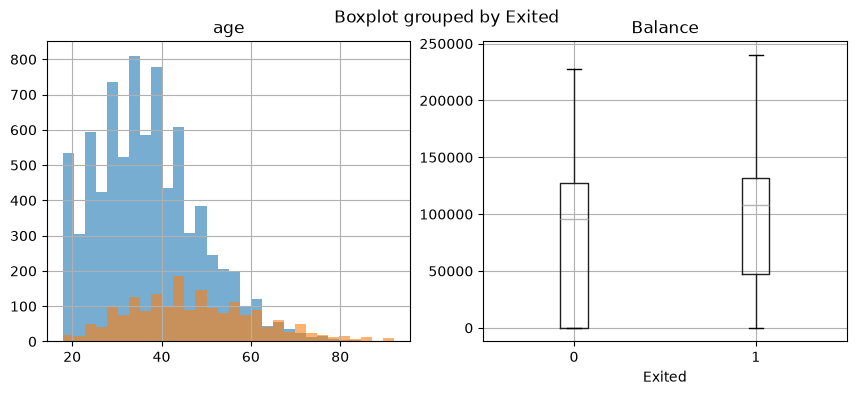

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))
df[df.Exited==0].Age.hist(ax=ax[0], bins=30, alpha=.6)
df[df.Exited==1].Age.hist(ax=ax[0], bins=30, alpha=.6)
ax[0].set_title('age')
df.boxplot('Balance', by='Exited', ax=ax[1])
plt.show()

In [9]:
# df.corr()  # breaks on strings
df.select_dtypes('number').corr()['Exited'].sort_values()

IsActiveMember    -0.146207
EstimatedSalary   -0.022465
CreditScore       -0.013992
HasCrCard          0.007024
Tenure             0.009408
NumOfProducts      0.031271
Balance            0.092151
Age                0.315760
Exited             1.000000
Name: Exited, dtype: float64

## model

Training code lives in `tulip_churn.train`. `uv run python -m tulip_churn.train` trains and saves `models/model.joblib` and `models/metrics.json`. The cells below call the same code to look at the results and do not save anything.

In [10]:
model, metrics = fit_and_evaluate(df, TrainConfig())
metrics['test']

{'n': 2000,
 'churn_rate': 0.176,
 'roc_auc': 0.7948,
 'accuracy': 0.844,
 'precision': 0.6163,
 'recall': 0.3011,
 'f1': 0.4046}

In [11]:
pd.concat({g: pd.DataFrame(v).T for g, v in metrics['by_group'].items()})

n  churn_rate  roc_auc  accuracy  precision  recall  \
Gender    Female    941.0      0.1998   0.7961    0.8183     0.5977  0.2766   
          Male     1059.0      0.1549   0.7921    0.8669     0.6353  0.3293   
AgeBand   30-39     630.0      0.1286   0.7177    0.8714     0.5000  0.1111   
          40-49     415.0      0.2072   0.7256    0.8145     0.6286  0.2558   
          50-59     236.0      0.3178   0.7224    0.6864     0.5128  0.2667   
          60+       119.0      0.5546   0.7247    0.6807     0.7059  0.7273   
          <30       600.0      0.0733   0.7148    0.9300     0.5833  0.1591   
Geography France   1048.0      0.1517   0.7840    0.8645     0.6076  0.3019   
          Germany   479.0      0.2630   0.7844    0.7871     0.6875  0.3492   
          Spain     473.0      0.1416   0.7958    0.8562     0.4828  0.2090   

                       f1  
Gender    Female   0.3782  
          Male     0.4337  
AgeBand   30-39    0.1818  
          40-49    0.3636  
          50-59    0.3509  
          60+      0.7164  
          <30      0.2500  
Geography France   0.4034  
          Germany  0.4632  
          Spain    0.2917